<a href="https://colab.research.google.com/github/arwendy123/Customer-Churn-Prediction-and-Analysis/blob/main/Customer_Churn_Prediction_in_Telecommunications_A_Machine_Learning_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reducing Customer Churn Through Data Analysis

## Executive Summary

This project analyzes telecom customer churn to identify the customer segments most at risk of leaving the company. The analysis shows that customers with month-to-month contracts, short tenure, higher monthly charges, electronic check payment methods, and no support or security services exhibit the highest churn risk. Based on these findings, the project proposes targeted retention actions to improve customer retention and reduce potential revenue loss.

## 1.) Business Problem

Customer churn is a major challenge for telecommunications companies because losing existing customers reduces recurring revenue and increases acquisition costs.

This project analyzes telecom customer data to identify the factors most associated with churn and to determine which customers should be prioritized for retention efforts.

### Business Questions
- Which customer groups have the highest churn rate?
- Does contract type affect churn?
- How does customer tenure relate to churn?
- Are higher charges associated with higher churn?
- Which customers should be targeted by retention campaigns?

### Objectives
- Measure the overall churn rate.
- Identify the strongest churn drivers.
- Segment high-risk customers.
- Provide retention recommendations based on the analysis.

The main focus of this project is generating actionable business insights and retention recommendations based on exploratory data analysis.

## 2.) Setup and Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
# Notebook configuration
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

This notebook is organized to support a business-oriented churn analysis. The primary focus is identifying high-risk customer segments and translating analytical findings into actionable retention recommendations.

## 3.) Data Overview

### 3.1 Load and Preview Dataset

Load the dataset and preview the first five records to understand the available variables and the overall structure of the data.

In [2]:
df = pd.read_csv('../data/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.2 Data Structure

Inspect the number of records, column names, data types, and non-null counts.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Observation:** The dataset contains 7,043 records and 21 columns. Most variables are categorical (`str`), while `SeniorCitizen` and `tenure` are stored as integers and `MonthlyCharges` is stored as a numeric (`float64`) variable. The `TotalCharges` column is still stored as a text (`str`) field and will require additional cleaning before numerical analysis.

### 3.3 Variable Type Summary

In [4]:
df.dtypes.value_counts()

str        18
int64       2
float64     1
Name: count, dtype: int64

**Observation:** The dataset is dominated by categorical variables (18 columns), which suggests that much of the churn analysis will focus on comparing churn rates across customer segments, service subscriptions, contract types, and payment methods.

### 3.4 Quick Summary



In [5]:
print(f'Total customers : {df.shape[0]:,}')
print(f'Total features  : {df.shape[1]}')
print(f'Churn rate      : {(df["Churn"] == "Yes").mean():.2%}')

Total customers : 7,043
Total features  : 21
Churn rate      : 26.54%


**Observation:** The dataset contains 7,043 customers and 21 features. The churn rate is approximately 26.5%, meaning about one in four customers left the company.

### 3.5 Missing Values

Check for missing values across all columns.

In [6]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({ 
    'Missing Values': missing, 
    'Percentage': (missing / len(df) * 100).round(2) 
})

missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percentage


**Observation:** No explicit missing values were detected using `isnull()`. However, the `TotalCharges` column may still contain blank strings that are not recognized as missing values.

### 3.6 Duplicate Records

In [7]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

**Observation:** No duplicate records were found in the dataset.

### 3.7 Initial Observations

Based on the initial inspection:
- The dataset contains **7,043 customer records** and **21 features**.
- The target variable is **`Churn`**.
- The overall churn rate is approximately **26.5%**.
- Most variables are categorical and describe customer services, contract type, and payment method.
- `TotalCharges` requires additional cleaning before further analysis.

The dataset is largely clean and suitable for business-oriented exploratory analysis.

## 4.) Data Cleaning

### 4.1 Inspect `TotalCharges`

The `TotalCharges` column is currently stored as a text field. Check for blank strings before converting it to a numeric type.

In [8]:
blank_totalcharges = (df['TotalCharges'].str.strip() == '').sum()

print(f'Blank values in TotalCharges: {blank_totalcharges}')

Blank values in TotalCharges: 11


**Observation:** The `TotalCharges` column contains 11 blank string values that are not detected by `isnull()`. These values must be handled before converting the column to a numeric type.

### 4.2 Convert `TotalCharges` to Numeric

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].dtype)

float64


**Observation:** `TotalCharges` has been successfully converted to a numeric (`float64`) variable. Invalid blank strings were converted into missing values (`NaN`).

### 4.3 Recheck Missing Values

In [10]:
missing_totalcharges = df['TotalCharges'].isnull().sum()

print(f'Missing values in TotalCharges: {missing_totalcharges}')

Missing values in TotalCharges: 11


**Observation:** After conversion, 11 missing values were identified in `TotalCharges`.

### 4.4 Investigate Rows with Missing `TotalCharges`

Inspect the records with missing `TotalCharges` to understand the cause of the missing values.

In [11]:
df[df['TotalCharges'].isnull()].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


**Observation:** The customers with missing `TotalCharges` have `tenure = 0`, indicating that they are newly joined customers who have not yet accumulated any charges.

### 4.5 Handle Missing Values

Because only 11 out of 7,043 records are affected (approximately 0.16% of the dataset), the incomplete records will be removed.

In [12]:
df = df.dropna(subset=['TotalCharges'])

print(df.shape)

(7032, 21)


**Observation:** The 11 incomplete records were removed, leaving 7,032 rows available for analysis.

### 4.6 Final Data Quality Check

In [13]:
print(f'Remaining rows : {df.shape[0]:,}')
print(f'Remaining columns : {df.shape[1]}')
print(f'Total missing : {df.isnull().sum().sum()}')
print(f'Duplicate records : {df.duplicated().sum()}')

Remaining rows : 7,032
Remaining columns : 21
Total missing : 0
Duplicate records : 0


### 4.7 Cleaning Summary

The following cleaning steps were performed:

- Identified 11 blank string values in `TotalCharges`. 
- Converted `TotalCharges` from text to numeric. 
- Verified that the affected records corresponded to customers with `tenure = 0`. 
- Removed the 11 incomplete records.

The dataset is now fully cleaned and ready for business-oriented exploratory analysis.

## 5.) Exploratory Analysis

This section explores the relationship between customer churn and key business variables, including contract type, tenure, monthly charges, payment method, and support-related services.

### 5.1 Overall Churn Distribution

Understand the proportion of customers who stayed versus customers who churned.

C:\Users\arwen\AppData\Local\Temp\ipykernel_22500\2109519626.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


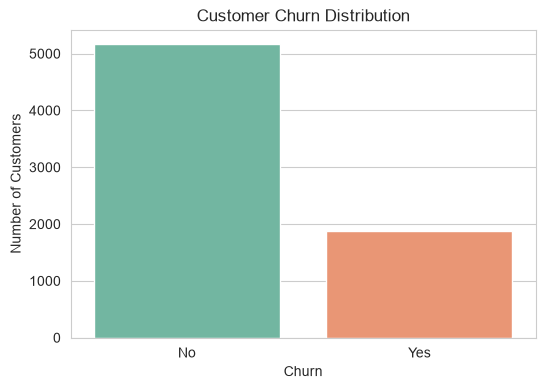

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

**Observation:** The dataset is moderately imbalanced, with most customers remaining with the company. Approximately 26.5% of customers churned, which is still a substantial proportion from a business perspective.

### 5.2 Contract Type vs Churn

Analyze how customer contract type is associated with churn behavior.

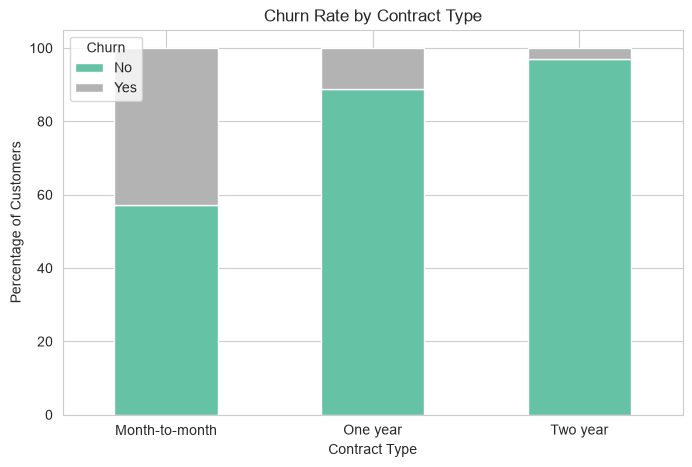

In [15]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.round(1)

contract_churn.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.show()

**Observation:** Month-to-month customers have the highest churn rate, while one-year and two-year contract customers churn substantially less. This indicates that contract commitment is one of the strongest retention factors in the dataset.

### 5.3 Tenure vs Churn

Examine whether customer tenure is related to churn.

C:\Users\arwen\AppData\Local\Temp\ipykernel_22500\91056495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')


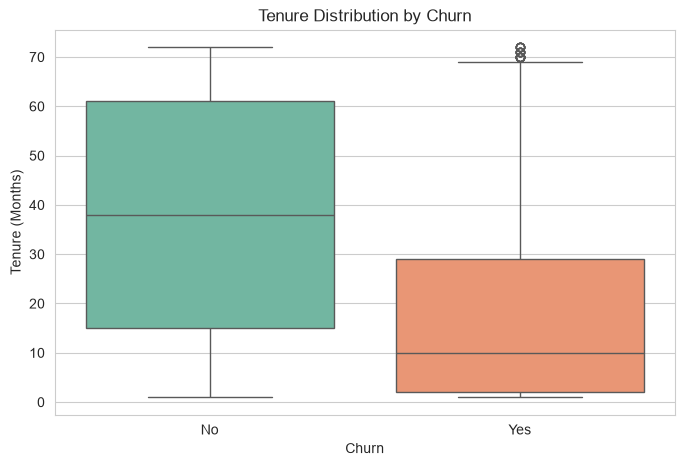

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')

plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

**Observation:** Customers who churn tend to have shorter tenure, while long-tenure customers are more likely to remain with the company. Churn risk appears to be highest during the early stages of the customer lifecycle.

### 5.4 Monthly Charges vs Churn

Compare monthly charges between customers who churned and those who stayed.

C:\Users\arwen\AppData\Local\Temp\ipykernel_22500\1649313979.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


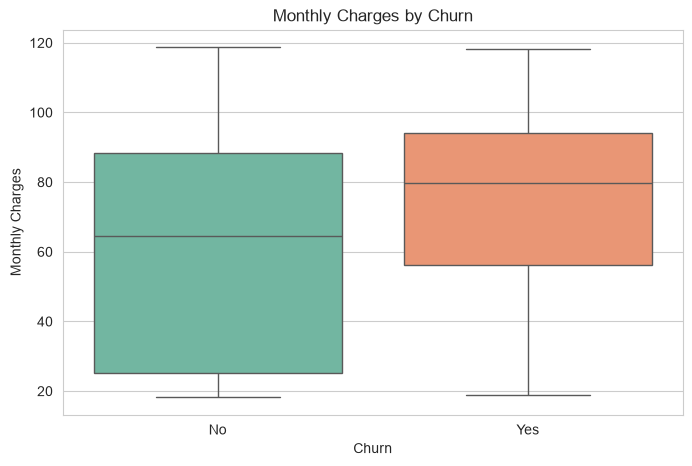

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')

plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

**Observation:** Customers who churn generally have higher monthly charges than customers who stay. This suggests that customers paying more each month may be more sensitive to perceived value and pricing relative to the services they receive.

### 5.5 Payment Method vs Churn

Evaluate whether churn differs across payment methods.

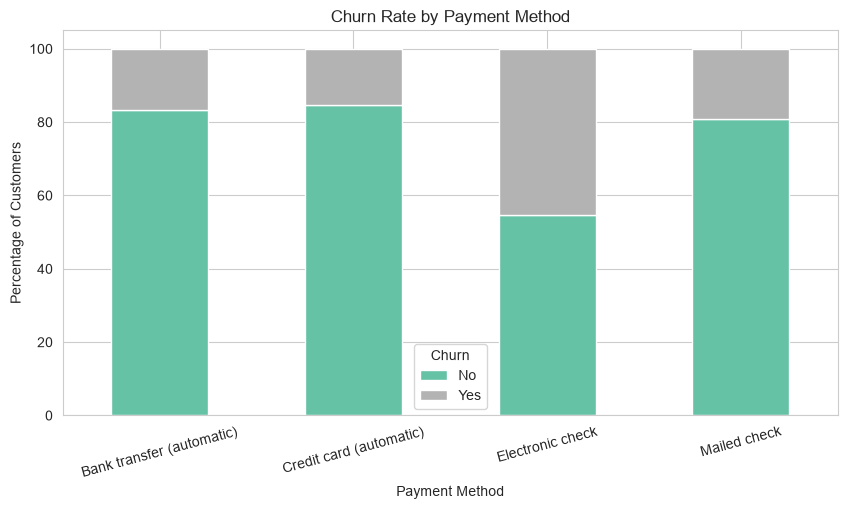

In [18]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

payment_churn.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=15)
plt.show()

**Observation:** Electronic check customers show the highest churn rate among all payment methods, suggesting that payment behavior may be associated with customer retention outcomes.

### 5.6 Support and Security Services vs Churn

Compare churn rates for customers with and without support-related services.

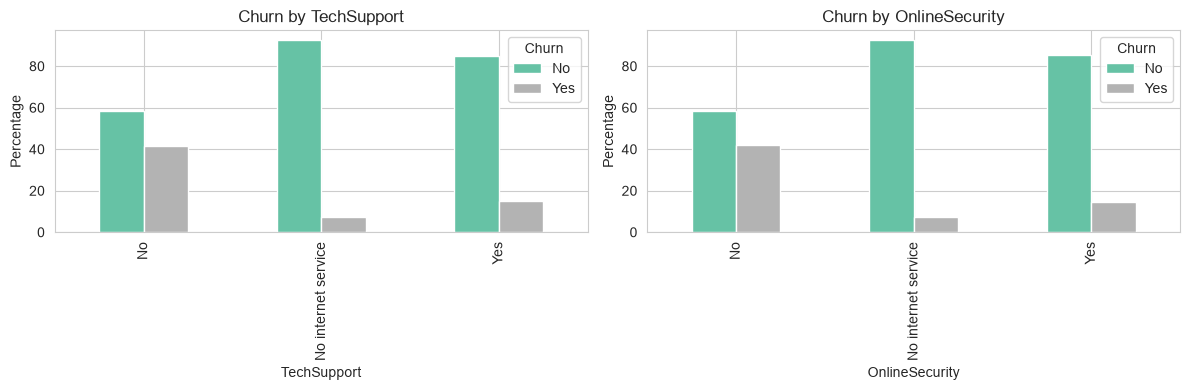

In [19]:
support_security = ['TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, support_security): 
    temp = pd.crosstab(df[col], df['Churn'], normalize='index') * 100 
    temp.plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(f'Churn by {col}') 
    ax.set_xlabel(col) 
    ax.set_ylabel('Percentage')

plt.tight_layout()
plt.show()

**Observation:** Customers without TechSupport and OnlineSecurity services exhibit noticeably higher churn rates. These services may increase customer stickiness and reduce the likelihood of churn.

### Key Takeaways from EDA

The exploratory analysis suggests that churn is concentrated among customers who:

- Have **month-to-month contracts** 
- Have **short tenure** 
- Pay **higher monthly charges** 
- Use **electronic check** as a payment method 
- Do **not** subscribe to **TechSupport** or **OnlineSecurity** 

These variables will be the primary focus of the business insight summary and retention recommendations.

## 6.) Business Insight Summary

The exploratory analysis reveals several customer characteristics that are strongly associated with churn risk. This section summarizes the findings from a business perspective and highlights the customer segments that should be prioritized for retention efforts.

### 6.1 High-Risk Customer Profile

Customers with the highest churn risk typically share the following characteristics: 
- **Month-to-month contract** 
- **Short tenure** 
- **Higher monthly charges** 
- **Electronic check payment method** 
- **No TechSupport subscription** 
- **No OnlineSecurity subscription** 

These characteristics suggest that churn is concentrated among customers who have low commitment, lower service attachment, and potentially higher perceived cost relative to value.

### 6.2 Most Influential Business Factors

| Factor | Business Interpretation | 
|---|---| 
| **Contract Type** | Strongest retention indicator; longer contracts are associated with lower churn. | 
| **Tenure** | Newer customers are substantially more likely to churn. | 
| **Monthly Charges** | Higher recurring charges are associated with increased churn risk. | 
| **Payment Method** | Electronic check customers show the highest churn concentration. | 
| **Support & Security Services** | Customers without these services are less retained. |

#### Churn Rate by Contract Type

In [20]:
(df.groupby('Contract')['Churn'] 
 .apply(lambda x: (x == 'Yes').mean()) 
 .mul(100) 
 .round(1) 
 .sort_values(ascending=False) 
 .to_frame('Churn Rate (%)'))

,Churn Rate (%)
Contract,
Month-to-month,42.7
One year,11.3
Two year,2.8


### 6.3 Customer Lifecycle Insight 

The analysis indicates that churn is not evenly distributed across the customer lifecycle. 

- Customers with **very short tenure** are the most vulnerable. 
- Customers who remain with the company for a longer period become increasingly stable. 
- Early retention appears to be more important than attempting to recover long-term loyal customers. 

This suggests that the first 12 months of the customer relationship are the most critical period for retention management.

### 6.4 Revenue Risk Perspective 

Customers who churn tend to pay higher monthly charges than customers who stay. Although the analysis does not directly calculate revenue loss, the pattern suggests that churn may disproportionately affect customers with higher recurring revenue. 

From a business perspective, reducing churn among high-charge customers could have a larger financial impact than reducing churn among low-charge customers.

### 6.5 Priority Retention Segment

Based on the combined findings, the highest-priority retention segment is: 

> **New customer + Month-to-month contract + High monthly charges + Electronic check + No TechSupport/OnlineSecurity**

This segment combines multiple risk factors and is likely to generate the highest concentration of future churn cases.

## 7.) Retention Recommendations

Based on the analysis, the following actions are recommended:

### 7.1 Improve Early Customer Retention 
- Introduce onboarding support during the first 3–12 months. 
- Monitor new customers with high monthly charges. 

### 7.2 Encourage Longer-Term Contracts 
- Offer incentives for migrating from month-to-month plans to one-year or two-year contracts. 

### 7.3 Target Electronic Check Customers 
- Promote automatic payment methods through discounts or convenience benefits. 

### 7.4 Increase Adoption of Support Services 
- Bundle TechSupport and OnlineSecurity with internet plans. 

### 7.5 Prioritize High-Value Customers 
- Focus retention efforts on customers with higher monthly charges, as their churn may have a larger revenue impact.

## Conclusion

The analysis shows that churn is primarily associated with low contract commitment, short customer tenure, higher monthly charges, electronic check payment behavior, and the absence of support and security services. These findings can help the company prioritize targeted retention initiatives and focus resources on the customer segments with the highest risk of future churn.